# 1. Configuração e Importação

Antes de começarmos a analisar e treinar nosso modelo, precisamos importar o dataset, e verificar se foi importado corretamente.

# Importação do Dataset

Ha métodos diferentes para importar o dataset, se estiver rodando VS Code, ou Colab. Rode a célula abaixo de acordo com o que você estiver usando.

## Colab (via URL)

In [1]:
print("\n-> 1. Baixando e Extraindo o Dataset")

# Limpeza Previa
!rm -f casting_512x512.zip

# Baixa o dataset usando a URL de download direto correta
!wget -q --show-progress -O casting_512x512.zip https://github.com/dnkamo/SC_TEC-M2_S07-Mini-Projeto-CNN-OpenCV-Pecas/raw/main/dataset/casting_512x512.zip

# Extrai o conteúdo
!unzip -q -o casting_512x512.zip
print("Download e extração concluídos!")


-> 1. Baixando e Extraindo o Dataset
casting_512x512.zip 100%[===================>]  30.69M  --.-KB/s    in 0.1s    
Download e extração concluídos!


## Arquivo Local

In [ ]:
print("\n-> 1. Extraindo o Dataset Localmente")

import os
import zipfile

# Definindo os caminhos corretos
nome_zip = "../dataset/casting_512x512.zip"
pasta_extraida = "casting_512x512"

# Verificando se o arquivo zip existe antes de tentar extrair
if os.path.exists(nome_zip):

    if not os.path.exists(pasta_extraida):

        print("Extraindo as imagens...")
        with zipfile.ZipFile(nome_zip, 'r') as zip_ref:

            zip_ref.extractall(pasta_extraida)

        print("Extração concluída!")
    else:
        print("O Dataset já está extraído!")
else:
    print(f"ERRO: O arquivo '{nome_zip}' não foi encontrado para extração.")

## Teste de Verificação

In [ ]:
# ========================================================
# Verificando se o dataset está extraído e pronto para usar

import os

pasta_extraida = 'casting_512x512'

if os.path.exists(pasta_extraida):
    print(f"Verificando a pasta: {pasta_extraida}")
    for root, dirs, files in os.walk(pasta_extraida):
        level = root.replace(pasta_extraida, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/ - {len(files)} arquivos")
else:
    print(f"ERRO: A pasta '{pasta_extraida}' não foi encontrada. Verifique se a extração ocorreu corretamente.")

Verificando a pasta: casting_512x512
casting_512x512/ - 0 arquivos
    def_front/ - 781 arquivos
    ok_front/ - 519 arquivos


# 2. Analise Exploratória com OpenCV

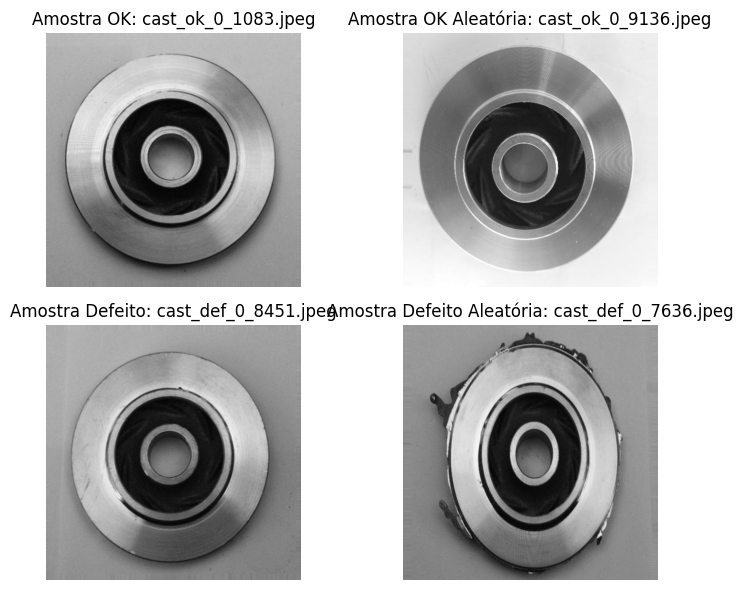

In [2]:
# =====================================
# 1. PEGANDO IMAGENS DE AMOSTRA
# =====================================

import cv2
import matplotlib.pyplot as plt
import os
import random

# Caminhos das pastas
dir_ok = 'casting_512x512/ok_front'
dir_def = 'casting_512x512/def_front'

# Para deixar as imagens consistentes, podemos pegar as primeiras
# imagens de cada pasta, ou podemos pegar uma imagem qualquer
# por meio de escolha aleatória

# METODO 1
# Pegando as primeiras imagens:
# ------------------------------------

# Listando os arquivos (pegando os primeiros 1 de cada)
img_ok_name = os.listdir(dir_ok)[0]
img_def_name = os.listdir(dir_def)[0]

# METODO 2
# Pegando imagens aleatórias:
# ------------------------------------

img_ok_name_random = os.listdir(dir_ok)
img_def_name_random = os.listdir(dir_def)

img_ok_choice_random = random.choice(img_ok_name_random)
img_def_choice_random = random.choice(img_def_name_random)

# Lendo as imagens com OpenCV
# ------------------------------------
# Primeiras
img_ok = cv2.imread(os.path.join(dir_ok, img_ok_name))
img_def = cv2.imread(os.path.join(dir_def, img_def_name))

# Aleatório
img_ok_random = cv2.imread(os.path.join(dir_ok, img_ok_choice_random))
img_def_random = cv2.imread(os.path.join(dir_def, img_def_choice_random))

# ------------------------------------
# Convertendo de BGR (OpenCV) para RGB (Matplotlib)
img_ok_rgb = cv2.cvtColor(img_ok, cv2.COLOR_BGR2RGB)
img_def_rgb = cv2.cvtColor(img_def, cv2.COLOR_BGR2RGB)

img_ok_rgb_random = cv2.cvtColor(img_ok_random, cv2.COLOR_BGR2RGB)
img_def_rgb_random = cv2.cvtColor(img_def_random, cv2.COLOR_BGR2RGB)

# Exibindo as amostras
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes[0, 0].imshow(img_ok_rgb)
axes[0, 0].set_title(f'Amostra OK: {img_ok_name}')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_ok_rgb_random)
axes[0, 1].set_title(f'Amostra OK Aleatória: {img_ok_choice_random}')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_def_rgb)
axes[1, 0].set_title(f'Amostra Defeito: {img_def_name}')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_def_rgb_random)
axes[1, 1].set_title(f'Amostra Defeito Aleatória: {img_def_choice_random}')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Aplicando filtros e convertendo em escala de cinza...


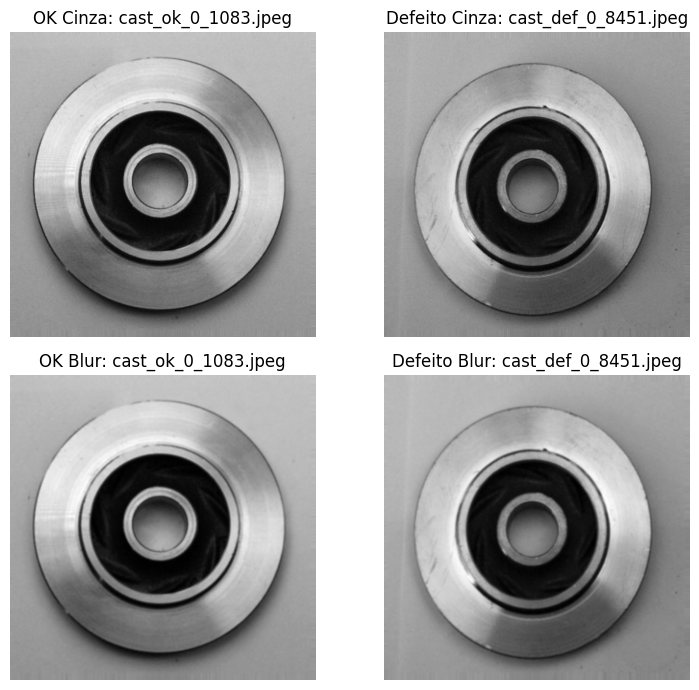

In [32]:
# ======================================================
# 2. APLICANDO FILTROS NAS IMAGENS
# ======================================================

# Com nossas amostras selecionadas, podemos aplicar
# conversão em escala de cinza, assim como filtros
# de suavização

print("Aplicando filtros e convertendo em escala de cinza...")

# ====
# A. Conversão para escala de cinza
# ---------------------------------
img_ok_cinza = cv2.cvtColor(img_ok_rgb, cv2.COLOR_RGB2GRAY)
img_def_cinza = cv2.cvtColor(img_def_rgb, cv2.COLOR_RGB2GRAY)

# ====
# B. Gaussian Blur ou Median Blur, para suavizar os detalhes
# ---------------------------------
# Variavel para usar no tamanho dos desfoque varias vezes de uma so vez
tamanho_desfoque = (5, 5)

img_ok_cinza_blur = cv2.GaussianBlur(img_ok_cinza, tamanho_desfoque, 0)
img_def_cinza_blur = cv2.GaussianBlur(img_def_cinza, tamanho_desfoque, 0)

#img_ok_cinza_blur = cv2.medianBlur(img_ok_cinza, tamanho_desfoque[0])
#img_def_cinza_blur = cv2.medianBlur(img_def_cinza, tamanho_desfoque[0])


# ====
# ---------------------------------
# Mostrando as imagens processadas até agora

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

# Exibindo imagens em escala de cinza
axes[0, 0].imshow(img_ok_cinza, cmap='gray')
axes[0, 0].set_title(f'OK Cinza: {img_ok_name}')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_def_cinza, cmap='gray')
axes[0, 1].set_title(f'Defeito Cinza: {img_def_name}')
axes[0, 1].axis('off')

# Exibindo imagens com Blur
axes[1, 0].imshow(img_ok_cinza_blur, cmap='gray')
axes[1, 0].set_title(f'OK Blur: {img_ok_name}')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_def_cinza_blur, cmap='gray')
axes[1, 1].set_title(f'Defeito Blur: {img_def_name}')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# 3. Destaque de Características

Processamento concluído!
Mostrando os resultados dos filtros:



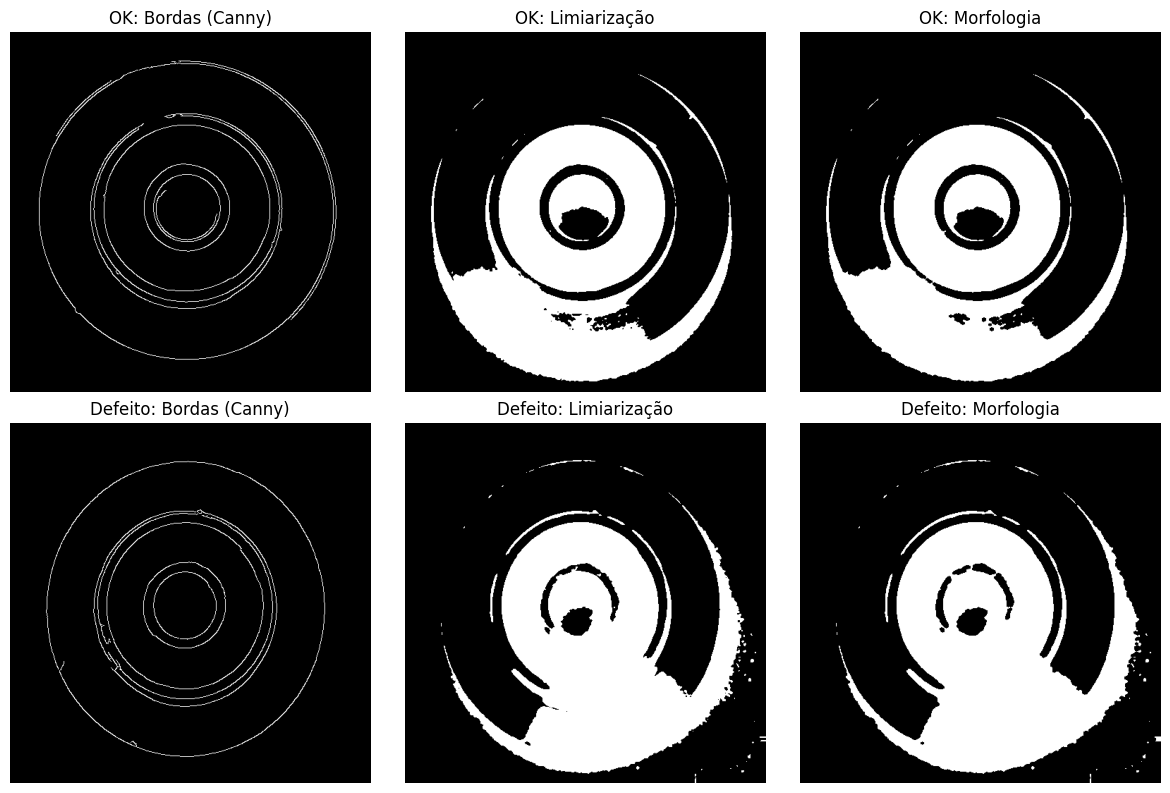

In [36]:
# ======================================================
# 3. DESTAQUE DE DETALHES (BORDAS) E LIMIARIZAÇÃO
# ======================================================

# Definição de hiperparâmetros para facilitar o ajuste
canny_min = 40
canny_max = 215
limiar_valor = 121

# ====
# A. Detecção de Bordas
# ---------------------------------

img_ok_bordas = cv2.Canny(img_ok_cinza_blur, canny_min, canny_max)
img_def_bordas = cv2.Canny(img_def_cinza_blur, canny_min, canny_max)

# ====
# B. Limiarização Binaria (Threshold)
# ---------------------------------

_, img_ok_limiar = cv2.threshold(img_ok_cinza_blur, limiar_valor, 255, cv2.THRESH_BINARY_INV)
_, img_def_limiar = cv2.threshold(img_def_cinza_blur, limiar_valor, 255, cv2.THRESH_BINARY_INV)

# ====
# C. Preenchendo Buracos (Operação Morfológica)
# ---------------------------------

# Definindo o kernel (matriz de estruturação)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# Aplicando o fechamento (Closing) para preencher buracos internos
img_ok_morph = cv2.morphologyEx(img_ok_limiar, cv2.MORPH_CLOSE, kernel)
img_def_morph = cv2.morphologyEx(img_def_limiar, cv2.MORPH_CLOSE, kernel)

print("Processamento concluído!")
print("Mostrando os resultados dos filtros:\n")

# Exibindo os resultados das etapas de destaque
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Coluna 1: Bordas (Canny)
axes[0, 0].imshow(img_ok_bordas, cmap='gray')
axes[0, 0].set_title('OK: Bordas (Canny)')
axes[1, 0].imshow(img_def_bordas, cmap='gray')
axes[1, 0].set_title('Defeito: Bordas (Canny)')

# Coluna 2: Limiarização (Threshold)
axes[0, 1].imshow(img_ok_limiar, cmap='gray')
axes[0, 1].set_title('OK: Limiarização')
axes[1, 1].imshow(img_def_limiar, cmap='gray')
axes[1, 1].set_title('Defeito: Limiarização')

# Coluna 3: Morfologia (Closing)
axes[0, 2].imshow(img_ok_morph, cmap='gray')
axes[0, 2].set_title('OK: Morfologia')
axes[1, 2].imshow(img_def_morph, cmap='gray')
axes[1, 2].set_title('Defeito: Morfologia')

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()

In [34]:
import ipywidgets as widgets
from ipywidgets import interact

# Filtros interativos para descobrir o melhor valor para detectar bordas

def update_filters(c_min, c_max, thresh):
    # Re-aplicando Canny com novos valores
    ok_edges = cv2.Canny(img_ok_cinza_blur, c_min, c_max)
    def_edges = cv2.Canny(img_def_cinza_blur, c_min, c_max)

    # Re-aplicando Threshold com novo valor
    _, ok_thresh = cv2.threshold(img_ok_cinza_blur, thresh, 255, cv2.THRESH_BINARY_INV)
    _, def_thresh = cv2.threshold(img_def_cinza_blur, thresh, 255, cv2.THRESH_BINARY_INV)

    # Plotagem
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes[0, 0].imshow(ok_edges, cmap='gray')
    axes[0, 0].set_title(f'OK: Canny ({c_min}, {c_max})')
    axes[0, 1].imshow(ok_thresh, cmap='gray')
    axes[0, 1].set_title(f'OK: Threshold ({thresh})')

    axes[1, 0].imshow(def_edges, cmap='gray')
    axes[1, 0].set_title(f'Defeito: Canny ({c_min}, {c_max})')
    axes[1, 1].imshow(def_thresh, cmap='gray')
    axes[1, 1].set_title(f'Defeito: Threshold ({thresh})')

    for ax in axes.flatten():
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Criando os controles interativos
interact(update_filters,
         c_min=widgets.IntSlider(min=0, max=255, step=1, value=40, description='Canny Min'),
         c_max=widgets.IntSlider(min=0, max=255, step=1, value=215, description='Canny Max'),
         thresh=widgets.IntSlider(min=0, max=255, step=1, value=125, description='Limiar'))

interactive(children=(IntSlider(value=40, description='Canny Min', max=255), IntSlider(value=215, description=…

<function __main__.update_filters(c_min, c_max, thresh)>

# 4. Ingestão de Dados e Augmentation (Keras)

In [ ]:
# ======================================================
# 4. DIVISÃO DE TREINO E VALIDAÇÃO (KERAS)
# ======================================================

import tensorflow as tf

# O Dataset já foi importado e verificado anteriormente para
# processar as imagens com OpenCV, portanto não iremos baixar
# ou verificar novamente

print("Separando em Treino, Validação e Teste:")

altura_img, largura_img = 512, 512
tamanho_lote = 32

dados_treino = tf.keras.utils.image_dataset_from_directory(
    pasta,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=(altura_img, largura_img),
    batch_size=tamanho_lote
)